# Análise: Perfil do Docente de Sucesso na UFRN

Esse arquivo foi feito por Ivo antes da nossa primeira reunião.

## Importando as bibliotecas necessárias

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

## Carregando Arquivo CSV

In [38]:
df = pd.read_csv("../2.0_dados_abertos_UFRN/1_limpeza_de_dados/databases/avaliacoes_Docentes_Turmas.csv", sep=";")
df = df.sort_values(by='ano')

## Informações gerais

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126294 entries, 88716 to 56
Data columns (total 28 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   nome                                  126294 non-null  object 
 1   sexo                                  126294 non-null  object 
 2   formacao                              126294 non-null  object 
 3   vinculo                               126294 non-null  object 
 4   categoria                             126294 non-null  object 
 5   classe_funcional                      126294 non-null  object 
 6   lotacao                               126294 non-null  object 
 7   id_turma                              126294 non-null  int64  
 8   ano                                   126294 non-null  int64  
 9   periodo                               126294 non-null  int64  
 10  qtd_discentes                         126294 non-null  int64  
 11  postu

## HeatMap de Correlações

O HeatMap de correlações foi plotado com o intuito de descobrir as correlações mais presentes entre as variáveis de nota e as outras variáveis da base. As correlações mais nítidas foram com as seguintes variáveis:

- Tempo de Admissão (Que será convertido em tempo de atuação para melhor interpretação)
- Classe funcional (Prof Adjunto, Prof Titular, etc)
- Formação Acadêmica (Mestrado, Doutorado, Graduação)

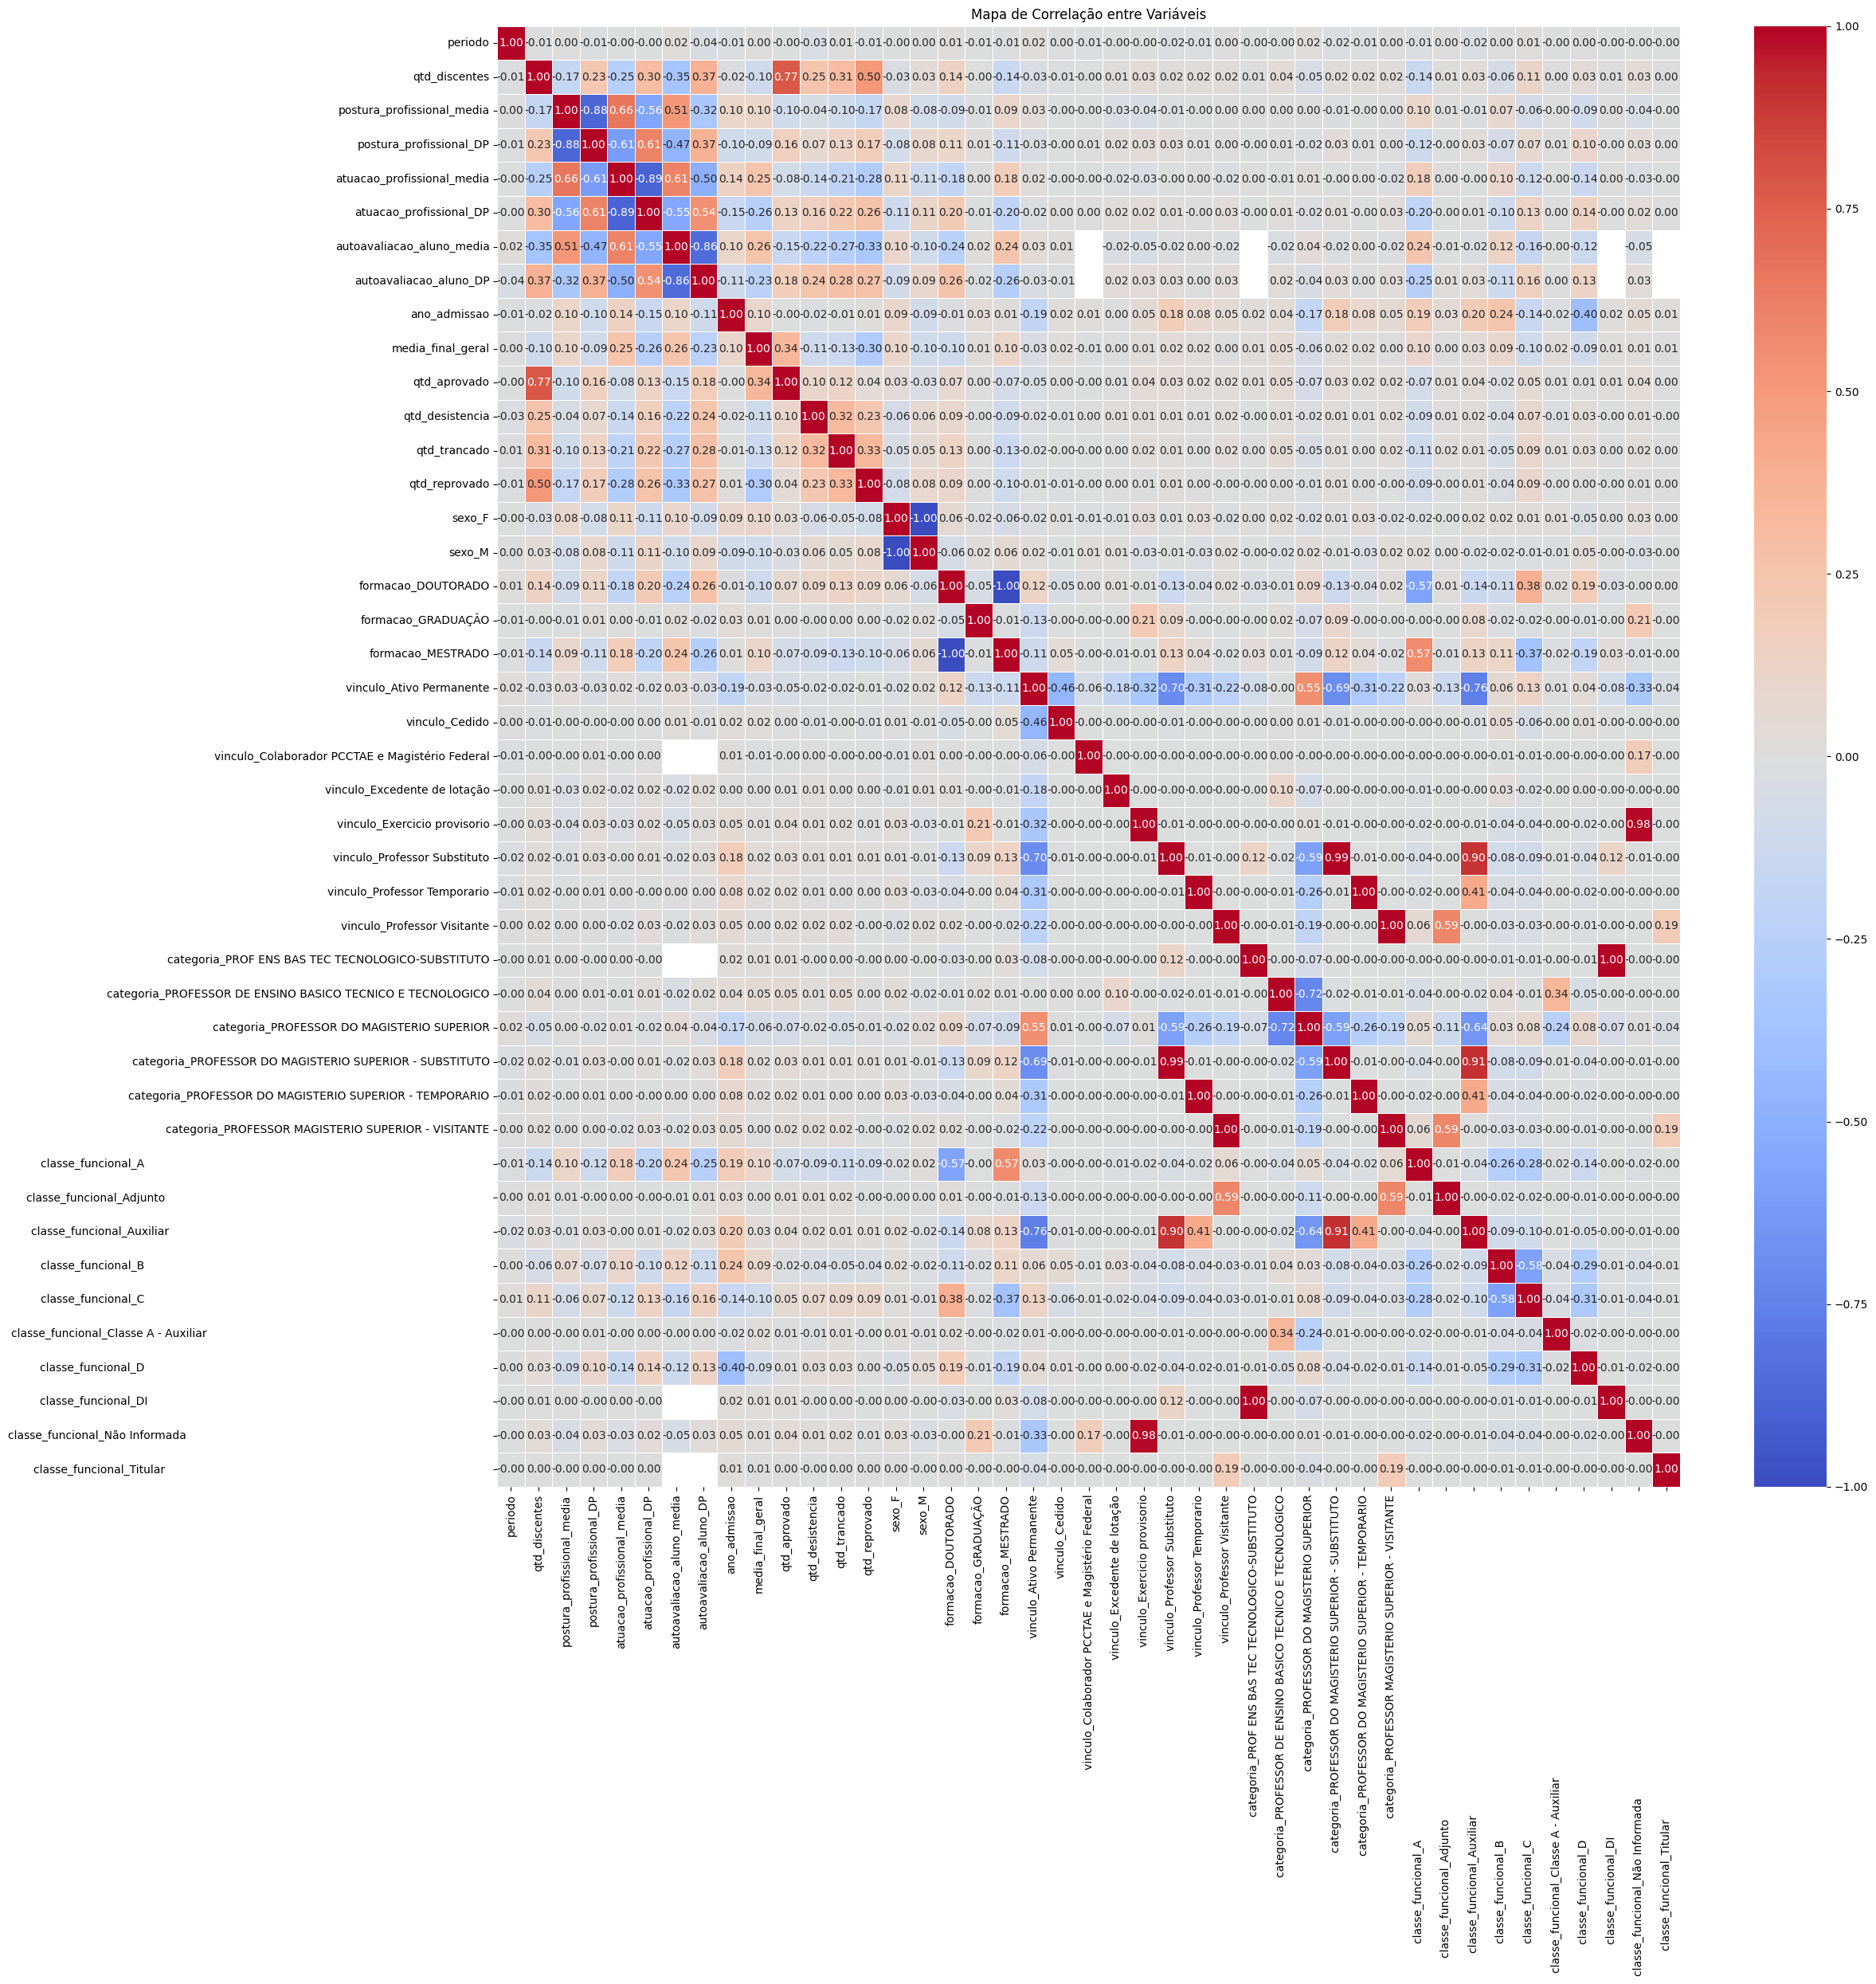

In [41]:
df_encoded = df.drop(columns=['nome', 'id_turma', 'lotacao','ano', 'qtd_aprovado_por_nota','qtd_reprovado_por_média_e_por_faltas','qtd_reprovado_por_faltas','qtd_reprovado_por_nota_e_falta','qtd_reprovado_por_nota']) #'qtd_discentes', 'lotacao'

df_encoded = pd.get_dummies(df_encoded)

correlacao = df_encoded.corr()

plt.figure(figsize=(25, 25))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Mapa de Correlação entre Variáveis")
plt.tight_layout()
plt.show()

## Separando DataFrames exclusivos para cada varíavel e as notas

- df_formacoes: Contém só os valores de formação e notas de cada professor
- df_funcionais: Contém só os valores de classe_funcional e notas de cada professor
- df_tempo_atuacao: Contém só os valores de tempo de atuação (2025 - ano de admissão) e as notas de cada professor

In [62]:
# Lista do nome das colunas de notas
notas = ['postura_profissional_media', 'atuacao_profissional_media', 'autoavaliacao_aluno_media','media_final_geral']

# Lista do nome das colunas de quantidades
quantidades = ['qtd_aprovado','qtd_reprovado','qtd_trancado','qtd_desistencia']

# DataFrame das formações e notas de cada professor
df_formacoes = pd.DataFrame()
df_formacoes['formacao'] = df['formacao']

# DataFrame das classes funcionais e notas de cada professor
df_funcionais = pd.DataFrame()
df_funcionais['classe_funcional'] = df['classe_funcional']

#DataFrame do gênero e notas de cada professor
df_genero = pd.DataFrame()
df_genero['genero'] = df['sexo']

# DataFrame do tempo de atuação e notas de cada professor
df_tempo_atuacao = pd.DataFrame()
df_tempo_atuacao['tempo_atuacao_anos'] = 2025 - df['ano_admissao']

# Preenche os DataFrames com as notas
for nota,quantidade in zip(notas,quantidades):
    df_formacoes[nota] = df[nota]
    df_funcionais[nota] = df[nota]
    df_genero[nota] = df[nota]
    df_formacoes[quantidade] = df[quantidade]
    df_funcionais[quantidade] = df[quantidade]
    df_genero[quantidade] = df[quantidade]


## Análise visual: Formação vs. Notas (Histograma)

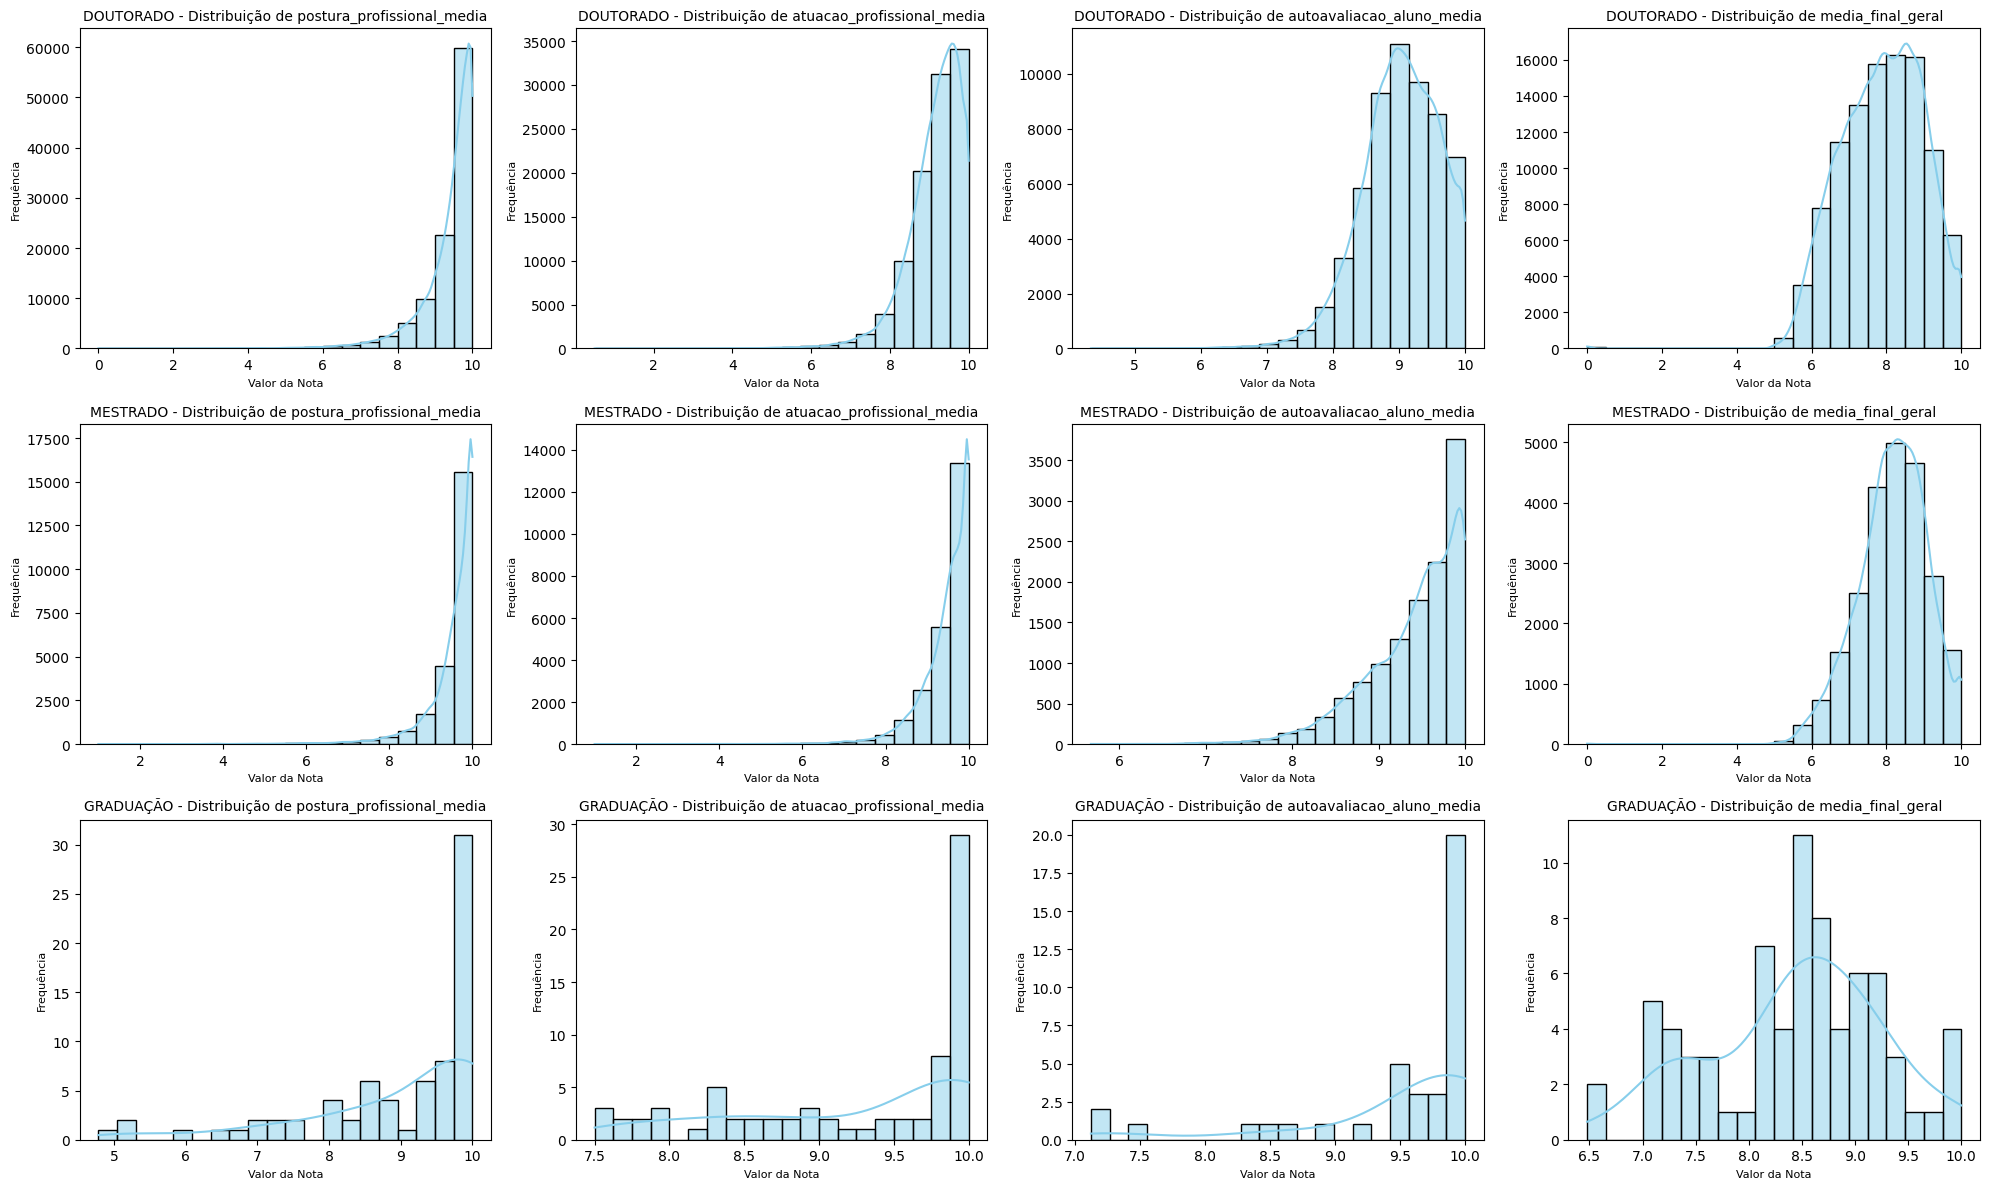

In [63]:
df_formacoes['formacao'] = df_formacoes['formacao'].replace({
    'ESPECIALIZAÇÃO': 'MESTRADO',
    'PÓS-DOUTORADO': 'DOUTORADO',
    'DESCONHECIDA': 'GRADUAÇÃO'
})

formacoes = df_formacoes['formacao'].unique()
n_rows = len(formacoes)
n_cols = len(notas)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()
ax_index = 0

for formacao in formacoes:
    for nota in notas:
        ax = axes[ax_index]

        sns.histplot(
            df_formacoes[df_formacoes['formacao'] == formacao][nota],
            bins=20, 
            kde=True,
            color='skyblue',
            ax=ax
        )

        ax.set_title(f'{formacao} - Distribuição de {nota}', fontsize=10)
        ax.set_xlabel('Valor da Nota', fontsize=8)
        ax.set_ylabel('Frequência', fontsize=8)

        ax_index += 1

plt.tight_layout()

plt.show()

## Análise visual: Formação vs. Quantidades (Histograma)

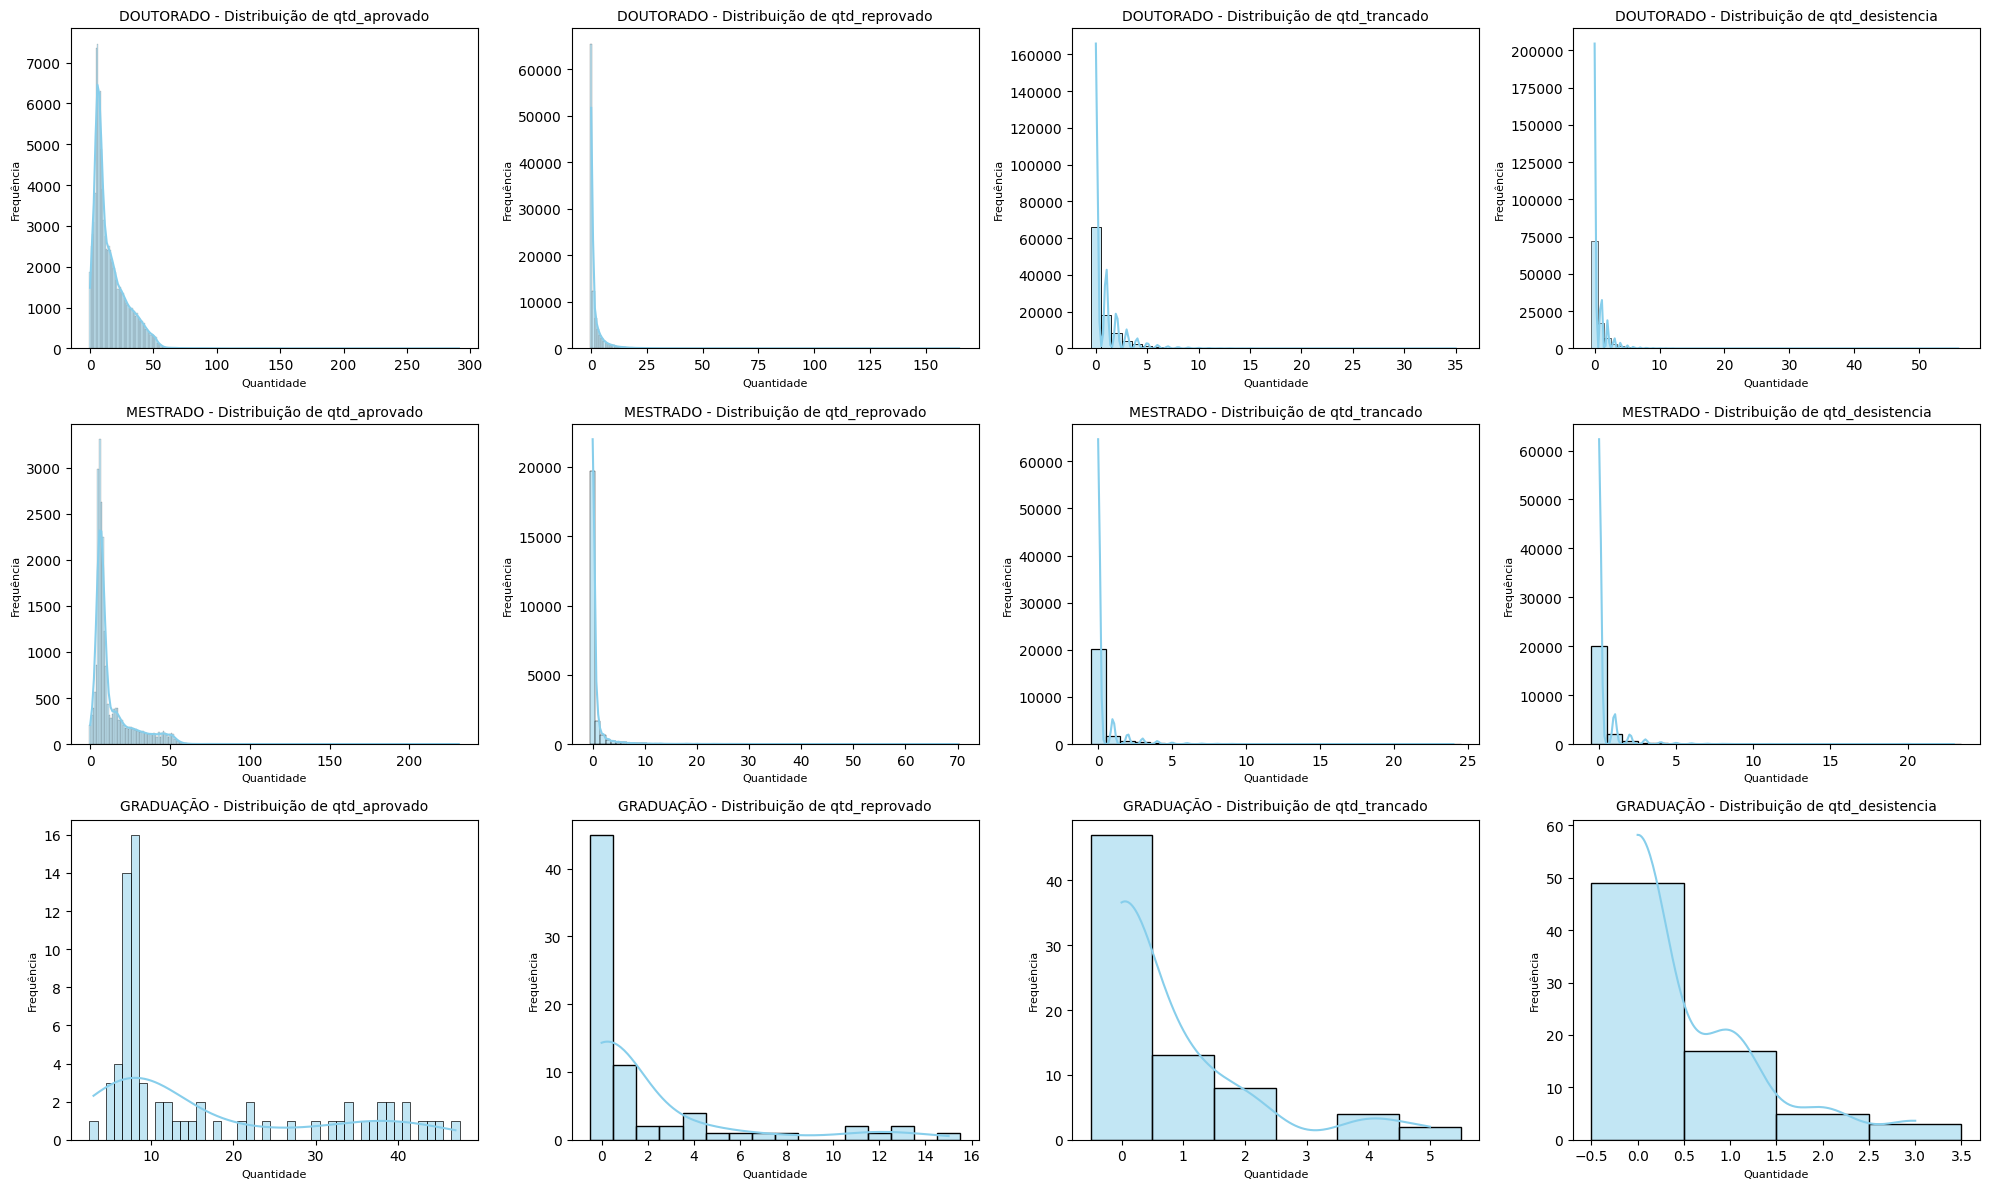

In [64]:
formacoes = df_formacoes['formacao'].unique()
n_rows = len(formacoes)
n_cols = len(quantidades)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()
ax_index = 0

for formacao in formacoes:
    for quantidade in quantidades:
        ax = axes[ax_index]

        sns.histplot(
            df_formacoes[df_formacoes['formacao'] == formacao][quantidade],
            bins=20,
            discrete=True, 
            kde=True,
            color='skyblue',
            ax=ax,
        )

        ax.set_title(f'{formacao} - Distribuição de {quantidade}', fontsize=10)
        ax.set_xlabel('Quantidade', fontsize=8)
        ax.set_ylabel('Frequência', fontsize=8)

        ax_index += 1

plt.tight_layout()

plt.show()

## Análise visual: Classe funcional vs. Notas (Histograma)

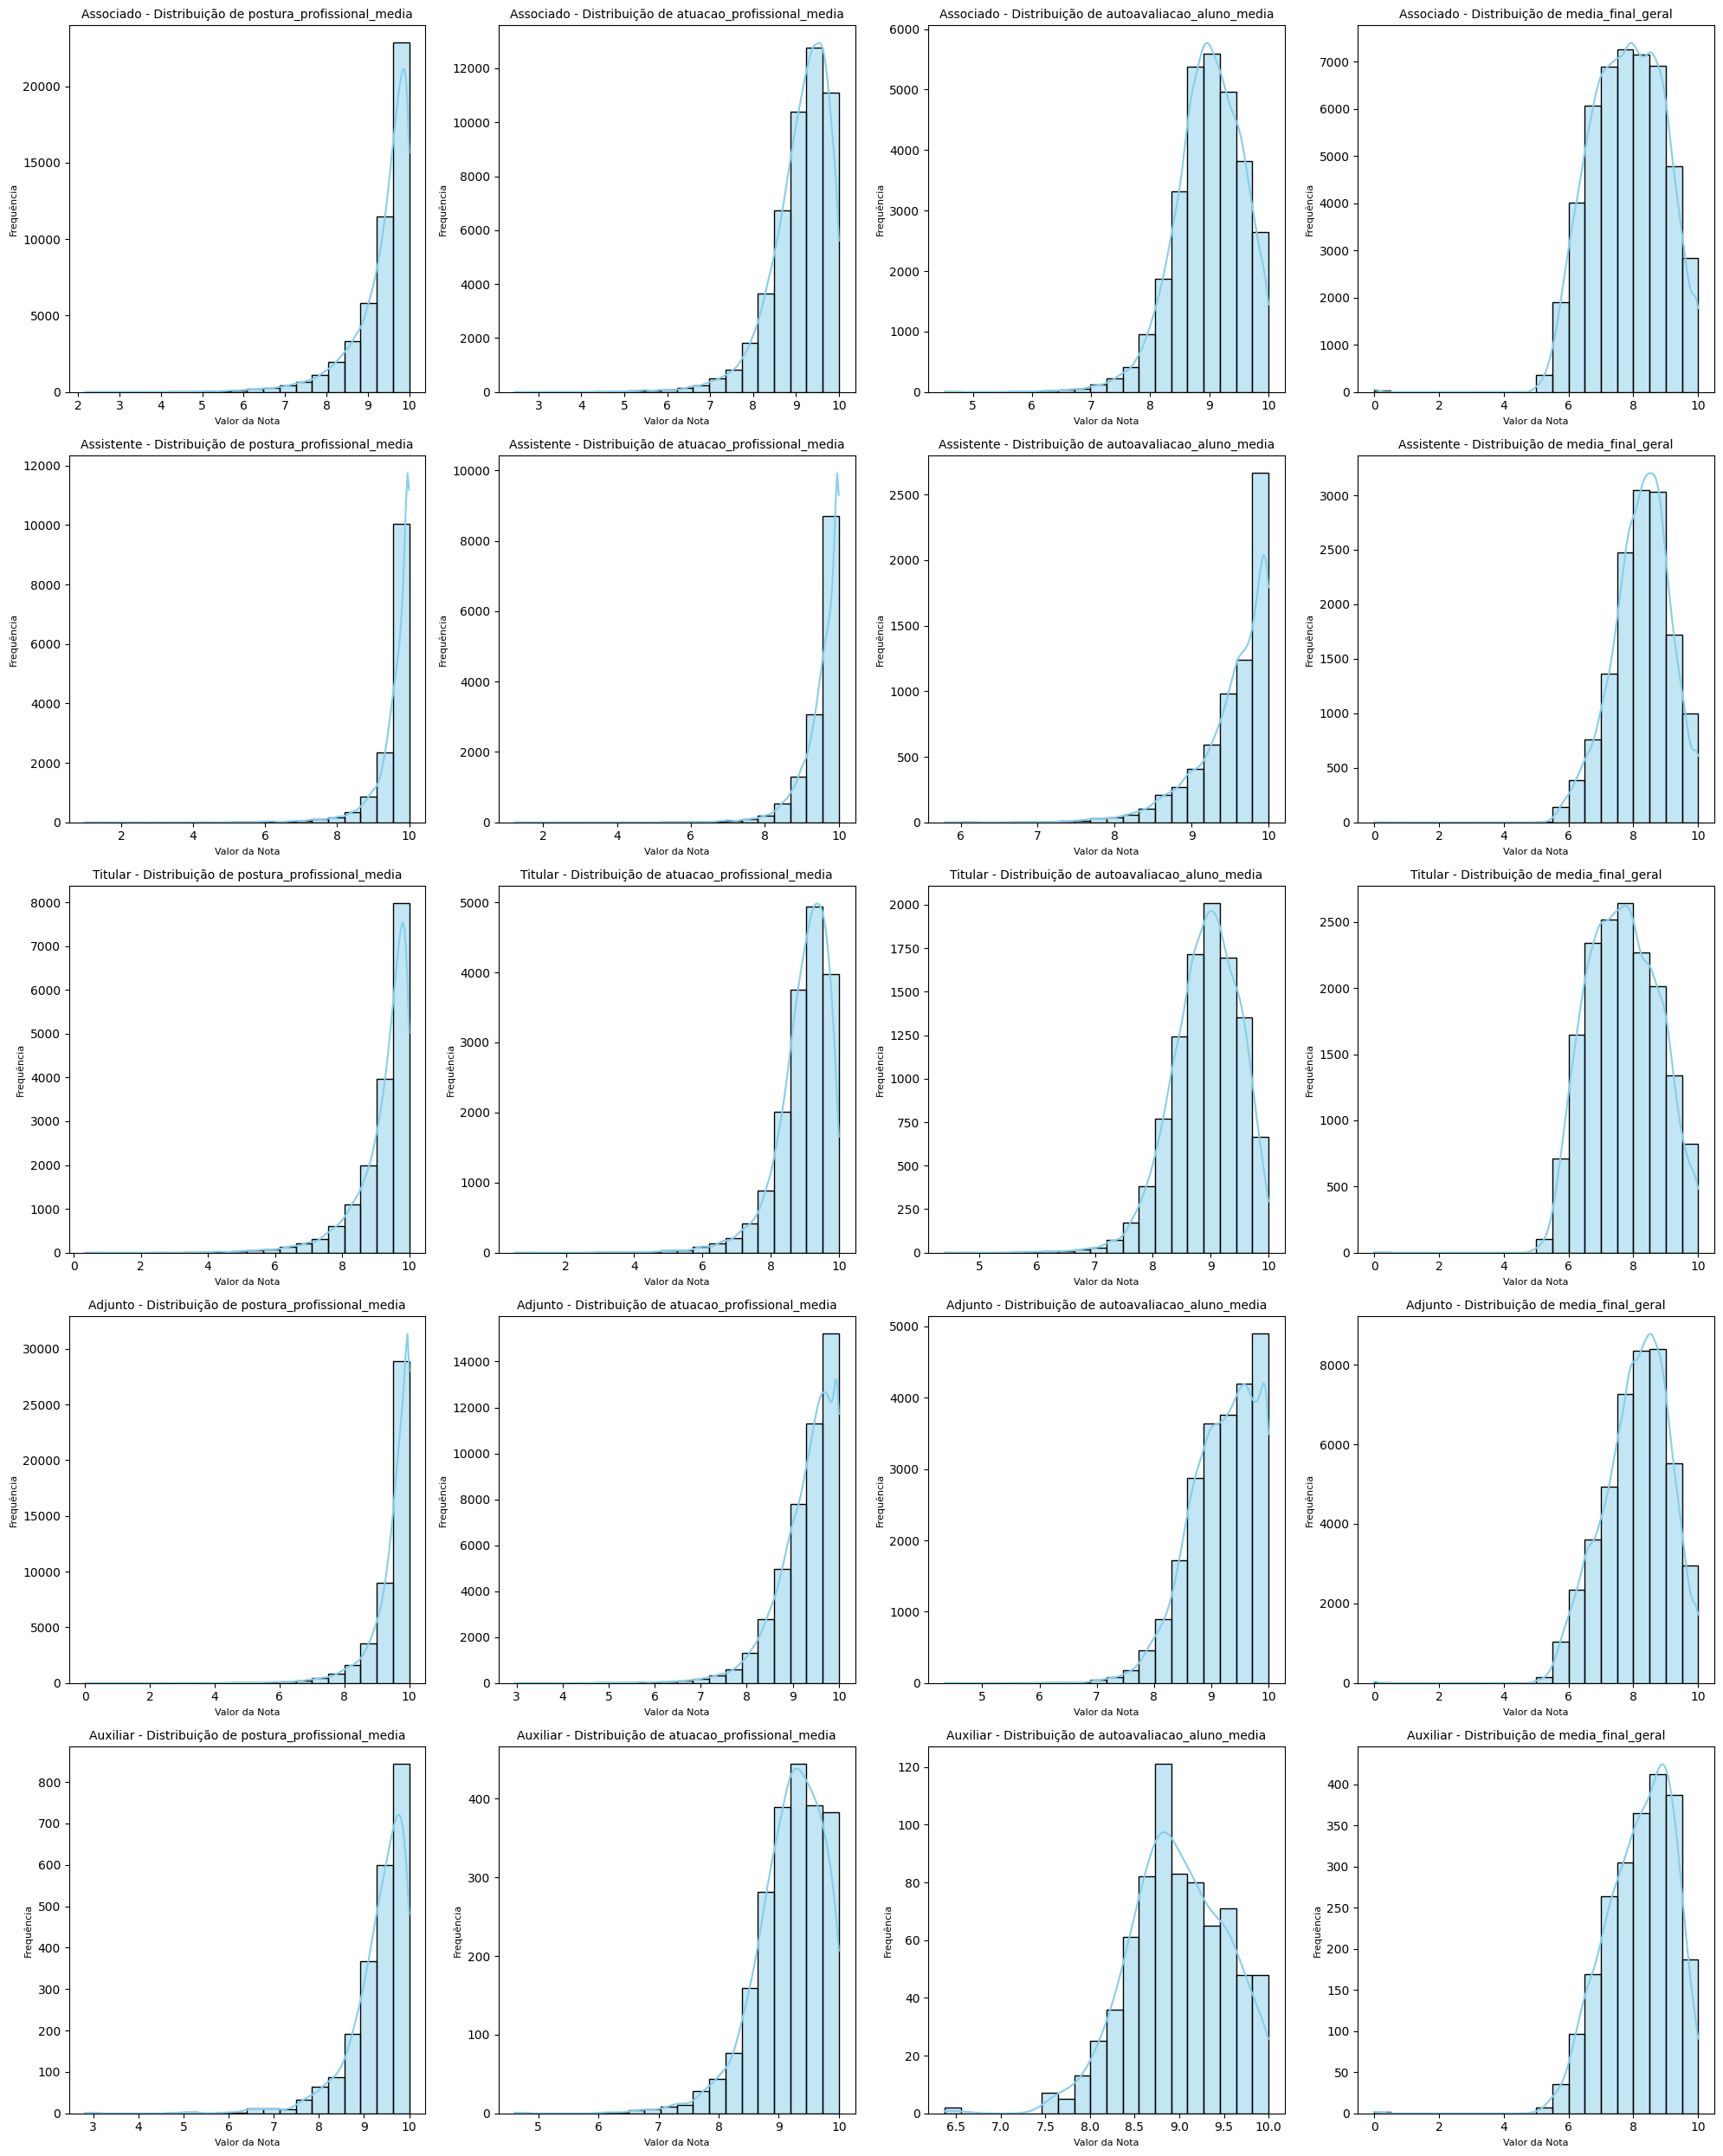

In [68]:
df_funcionais['classe_funcional'] = df_funcionais['classe_funcional'].str.strip()

valores_a_remover = ['Não Informada', 'DI']

filter_isin = ~df_funcionais['classe_funcional'].isin(valores_a_remover)

df_funcionais = df_funcionais[filter_isin]
df_funcionais['classe_funcional'] = df_funcionais['classe_funcional'].replace({
    'A': 'Assistente',
    'Classe A - Auxiliar': 'Auxiliar',
    'B': 'Adjunto',
    'C': 'Associado',
    'D': 'Titular'
})

classes_funcionais = df_funcionais['classe_funcional'].unique()

n_rows = len(classes_funcionais)
n_cols = len(notas)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows + 5))
axes = axes.flatten()
ax_index = 0

for classe_funcional in classes_funcionais:
    for nota in notas:
        ax = axes[ax_index]

        if nota in df_funcionais.columns:
            data_to_plot = df_funcionais[df_funcionais['classe_funcional'] == classe_funcional][nota]
            
            if not data_to_plot.empty:
                sns.histplot(
                    data_to_plot,
                    bins=20,
                    kde=True,
                    color='skyblue',
                    ax=ax
                )
            
                ax.set_title(f'{classe_funcional} - Distribuição de {nota}', fontsize=10)
                ax.set_xlabel('Valor da Nota', fontsize=8)
                ax.set_ylabel('Frequência', fontsize=8)
            else:
                ax.set_title(f'{classe_funcional} - Sem Dados para {nota}', fontsize=10)
                ax.set_xlabel('N/A', fontsize=8)

        ax_index += 1

plt.tight_layout()
plt.show()

## Análise visual: Classe funcional vs. quantidades (Histograma)

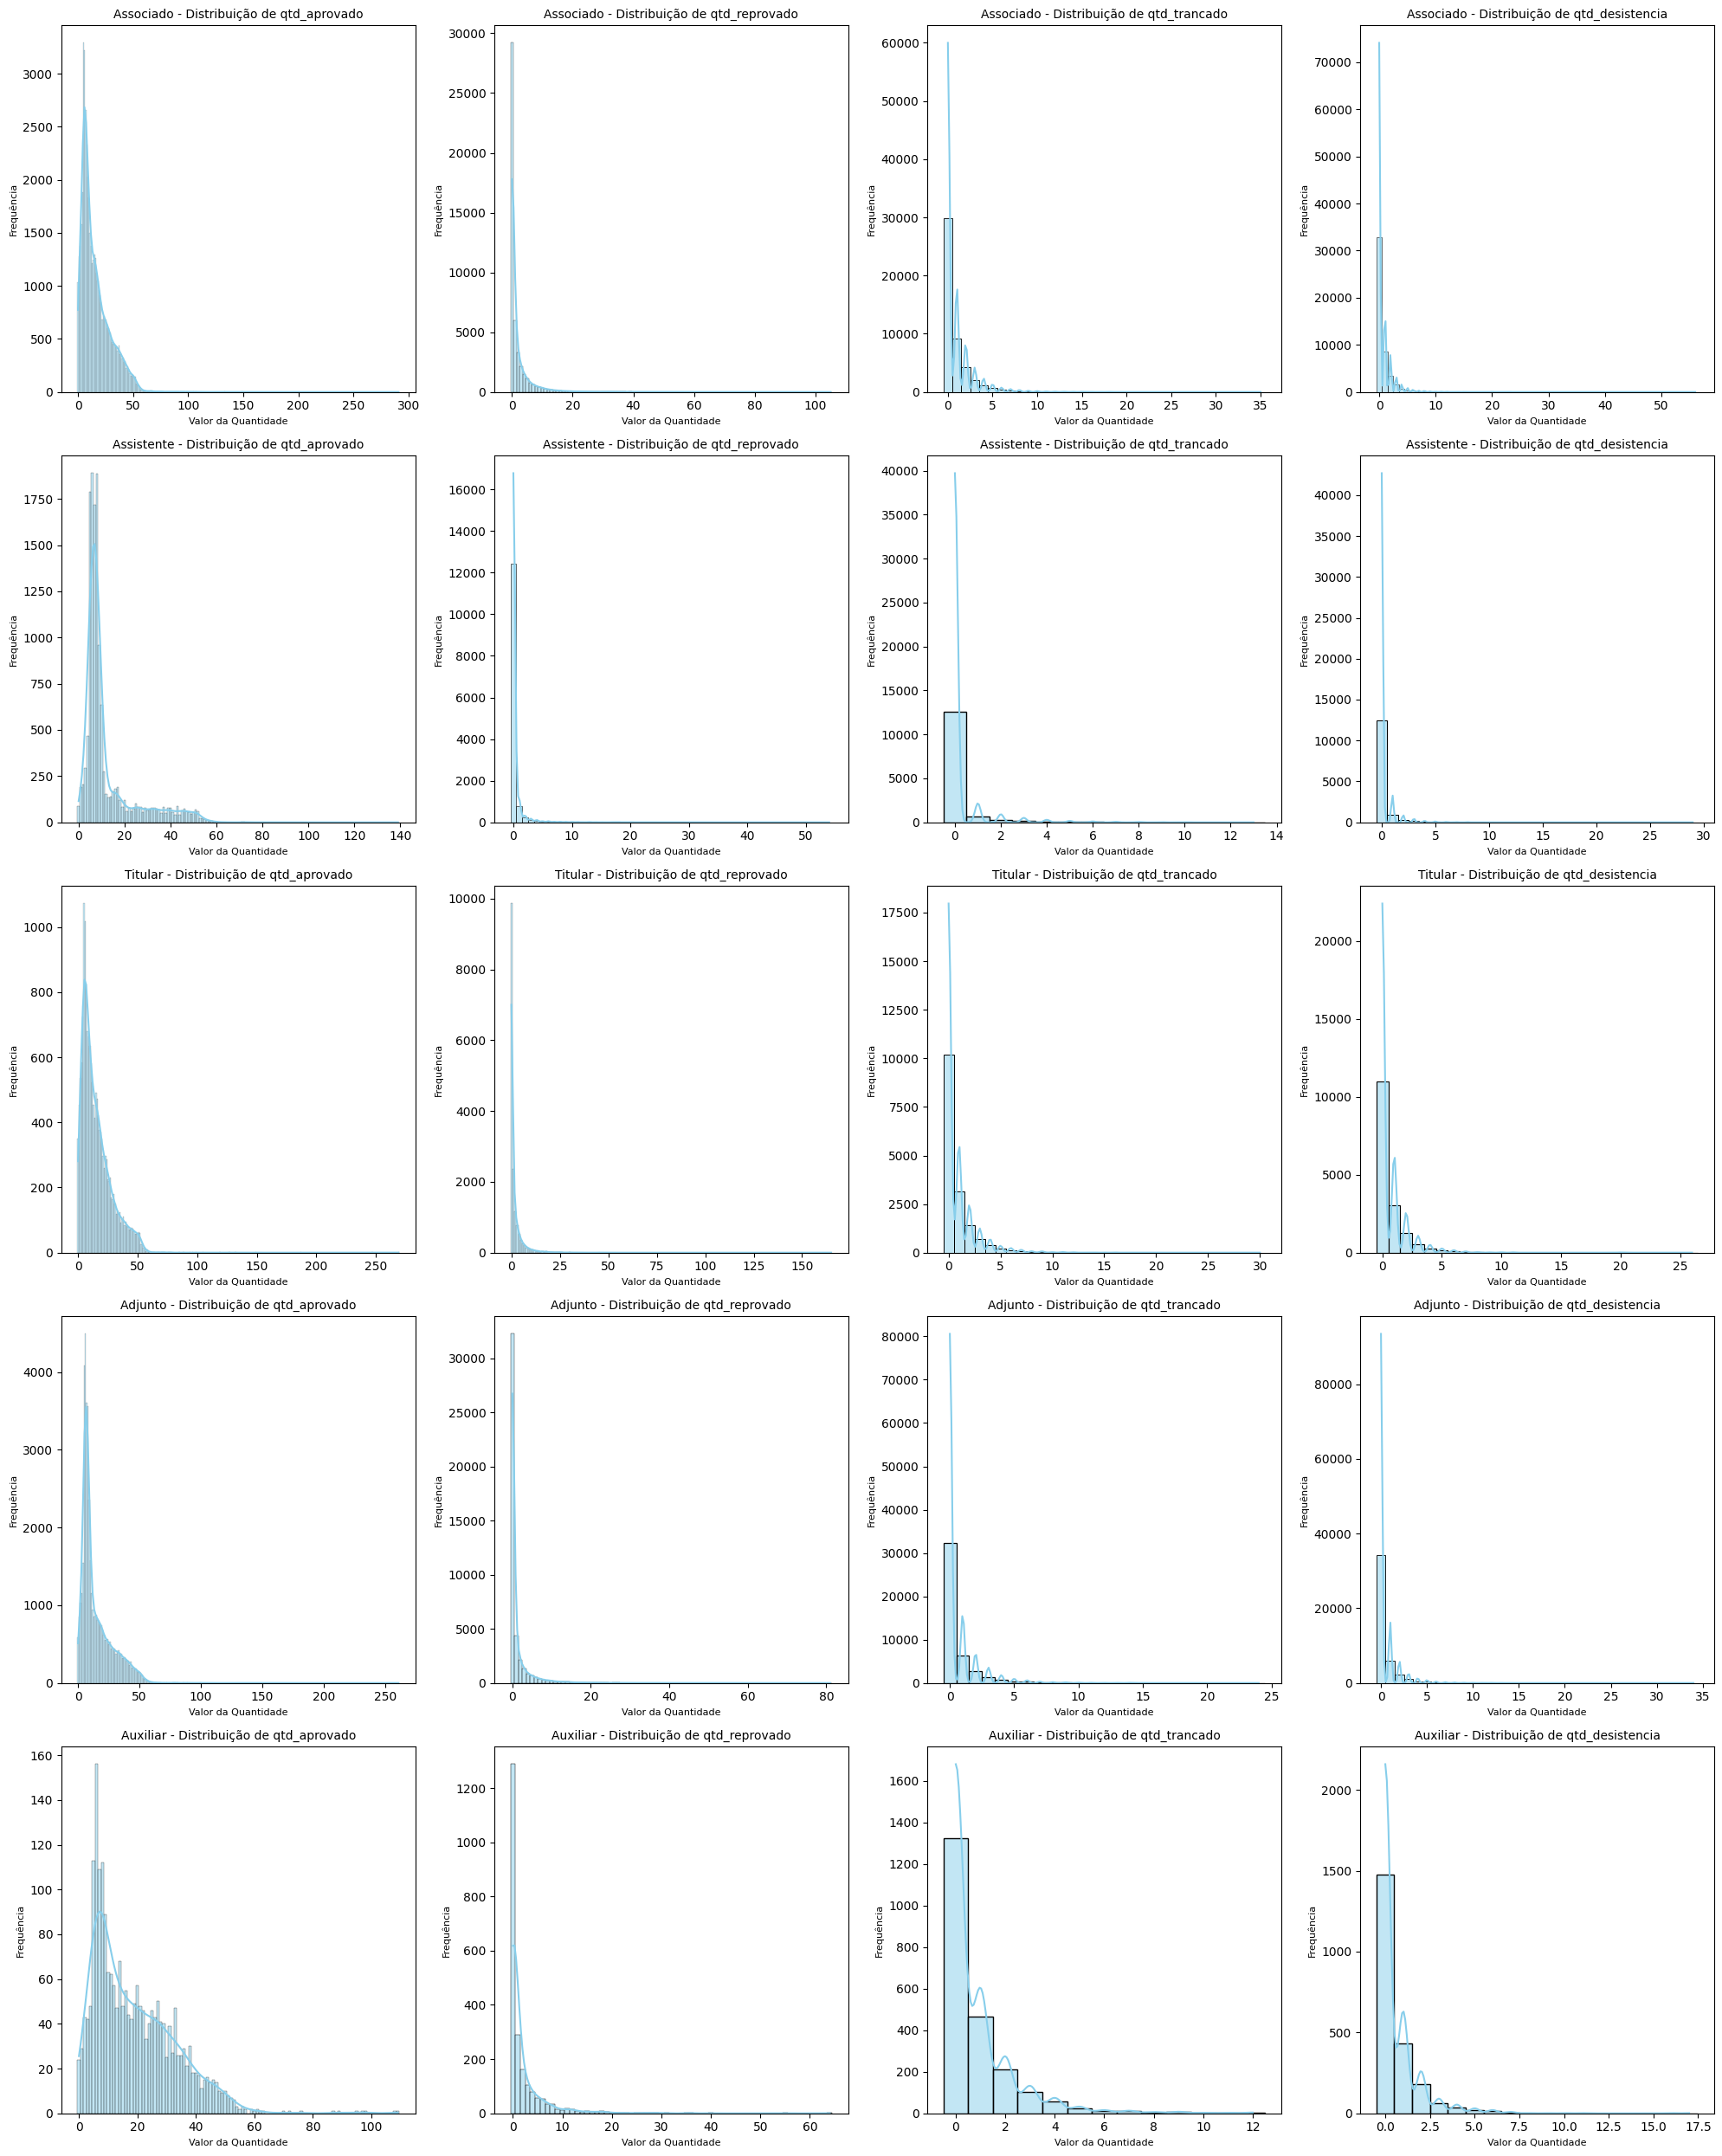

In [69]:
classes_funcionais = df_funcionais['classe_funcional'].unique()

n_rows = len(classes_funcionais)
n_cols = len(quantidades)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows + 5))
axes = axes.flatten()
ax_index = 0

for classe_funcional in classes_funcionais:
    for quantidade in quantidades:
        ax = axes[ax_index]

        if quantidade in df_funcionais.columns:
            data_to_plot = df_funcionais[df_funcionais['classe_funcional'] == classe_funcional][quantidade]
            
            if not data_to_plot.empty:
                sns.histplot(
                    data_to_plot,
                    bins=20,
                    discrete=True,
                    kde=True,
                    color='skyblue',
                    ax=ax
                )
            
                ax.set_title(f'{classe_funcional} - Distribuição de {quantidade}', fontsize=10)
                ax.set_xlabel('Valor da Quantidade', fontsize=8)
                ax.set_ylabel('Frequência', fontsize=8)
            else:
                ax.set_title(f'{classe_funcional} - Sem Dados para {quantidade}', fontsize=10)
                ax.set_xlabel('N/A', fontsize=8)

        ax_index += 1

plt.tight_layout()
plt.show()

## Análise visual: Gênero vs. Notas (Histograma)

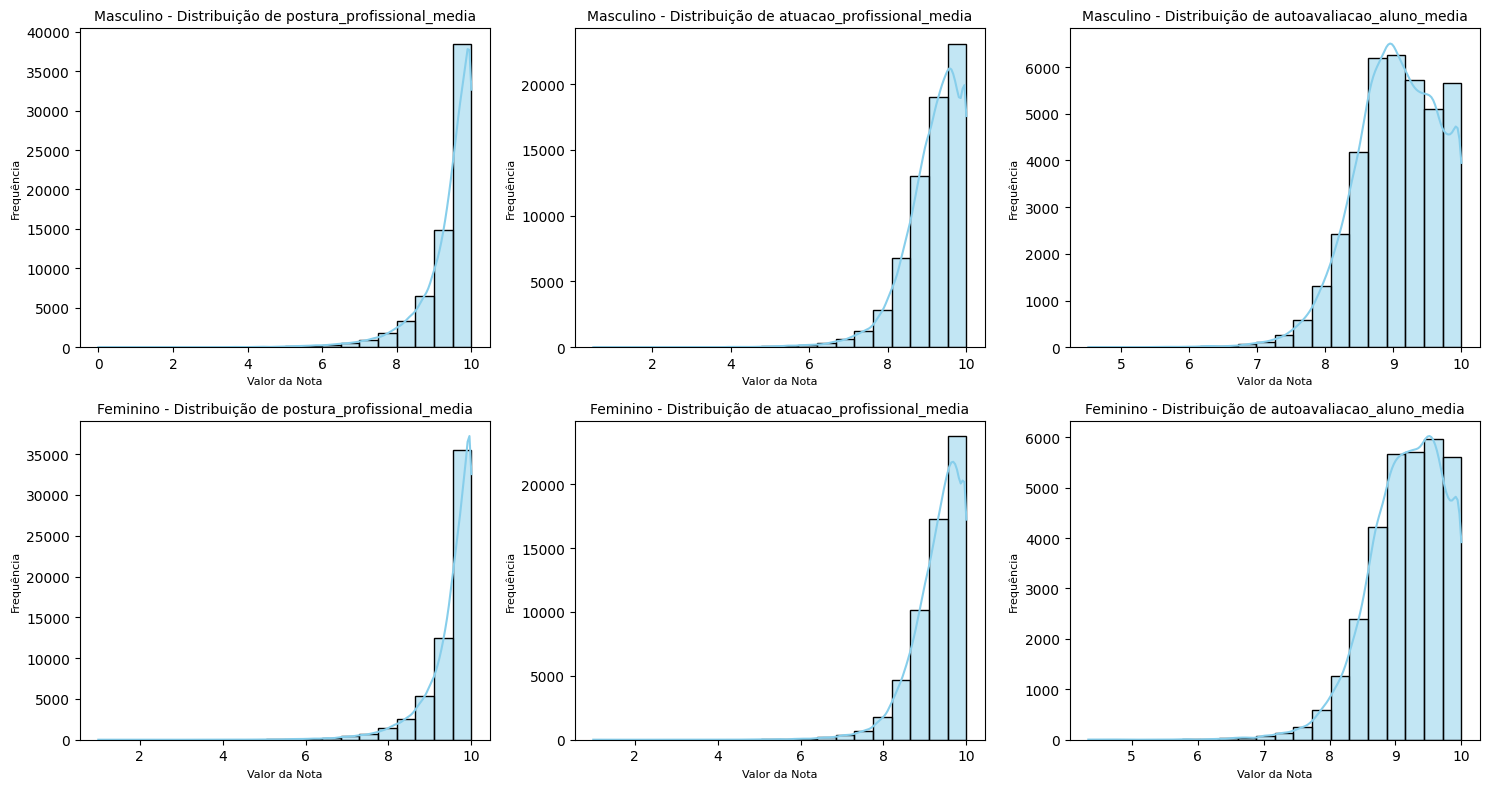

In [15]:
df_genero = df_genero.replace(
    {
        'M': 'Masculino',
        'F': 'Feminino'
    }
)

generos = df_genero['genero'].unique()
n_rows = len(generos)
n_cols = len(notas)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()
ax_index = 0

for genero in generos:
    for nota in notas:
        ax = axes[ax_index]

        sns.histplot(
            df_genero[df_genero['genero'] == genero][nota],
            bins=20, 
            kde=True,
            color='skyblue',
            ax=ax
        )

        ax.set_title(f'{genero} - Distribuição de {nota}', fontsize=10)
        ax.set_xlabel('Valor da Nota', fontsize=8)
        ax.set_ylabel('Frequência', fontsize=8)

        ax_index += 1

plt.tight_layout()

plt.show()

## Análise visual: Gênero vs. Quantidades

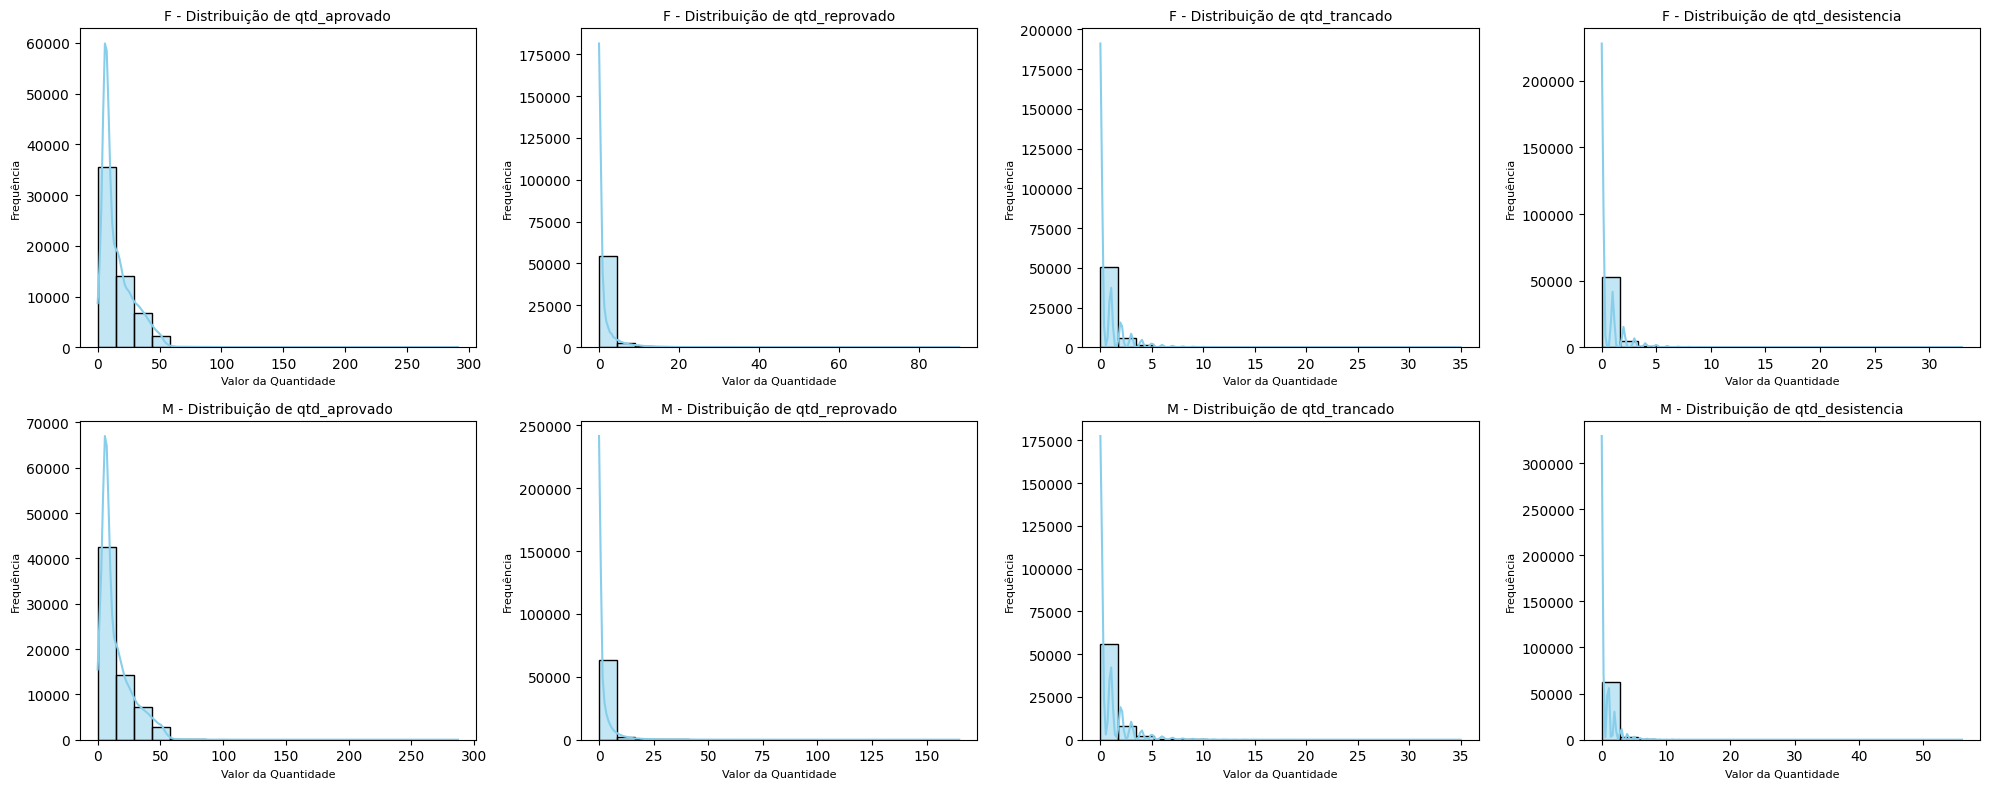

In [70]:
generos = df_genero['genero'].unique()
n_rows = len(generos)
n_cols = len(quantidades)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()
ax_index = 0

for genero in generos:
    for quantidade in quantidades:
        ax = axes[ax_index]

        sns.histplot(
            df_genero[df_genero['genero'] == genero][quantidade],
            bins=20, 
            kde=True,
            color='skyblue',
            ax=ax
        )

        ax.set_title(f'{genero} - Distribuição de {quantidade}', fontsize=10)
        ax.set_xlabel('Valor da Quantidade', fontsize=8)
        ax.set_ylabel('Frequência', fontsize=8)

        ax_index += 1

plt.tight_layout()

plt.show()